# Food Delivery Time Prediction – Deep Learning Project

---

## Project Overview
This project implements multiple **deep learning architectures** to predict **food delivery time** based on delivery person attributes, geographic locations, order type, vehicle type, and calculated travel distance.

The goal is to build accurate **regression models** that estimate delivery duration and identify the most influential factors affecting delivery time.

---

## Dataset Description
The dataset consists of historical food delivery records containing:

- Delivery person details *(age, ratings, ID)*
- Restaurant location coordinates
- Delivery location coordinates
- Type of order *(Snack, Drinks, Buffet, Meal)*
- Type of vehicle *(motorcycle, scooter, bicycle, electric scooter)*
- **Target variable:** Time taken for delivery (minutes)

**Dataset Shape**
- Initial: **45,593 rows × 11 columns**
- After cleaning & feature engineering: **41,953 rows × 12 columns**

---

## Data Preprocessing Steps

### Data Cleaning
- Removed rows with **zero latitude/longitude values** (invalid locations)
- Capped delivery person ratings at **5.0**
- Checked for duplicate records *(none found)*

---

### Feature Engineering

#### a) Distance Calculation
- Used the **Haversine formula** to compute great-circle distance
- Earth radius assumed: **6367 km**
- Accounts for Earth’s curvature
- Produces accurate real-world travel distance

---

#### b) Categorical Encoding
- One-Hot Encoding applied to:
  - `Type_of_order`
  - `Type_of_vehicle`
- Used `drop_first=True` to avoid multicollinearity
- Added **6 binary features**

---

#### c) Feature Scaling
- Applied **PowerTransformer (Yeo–Johnson method)** to:
  - Delivery_person_Age
  - Delivery_person_Ratings
  - Restaurant_latitude
  - Restaurant_longitude
  - Delivery_location_latitude
  - Delivery_location_longitude
  - Distance

**Why Yeo–Johnson?**
- Handles both positive and negative values
- Reduces skewness
- Standardizes variance
- Improves neural network convergence

---

### Train–Test Split
- **Training set:** 80% → 33,562 samples  
- **Testing set:** 20% → 8,391 samples  
- Stratified by delivery time to preserve distribution

---

## Deep Learning Models Implemented

### Simple ANN (Artificial Neural Network)
- **Architecture:**  
  Dense(256) → Dropout(0.3) → BatchNorm →  
  Dense(64) → Dropout(0.3) → BatchNorm →  
  Dense(32) → Dropout(0.3) → Dense(1)
- **Activation:** ReLU (hidden), Linear (output)
- **Optimizer:** Adam (LR = 0.01)
- **Loss:** Mean Squared Error
- **Epochs:** 50  
- **Batch size:** 64

---

### LSTM (Long Short-Term Memory)
- Input reshaped to `(samples, timesteps=1, features=13)`
- **Architecture:**  
  LSTM(128, return_sequences=True) → Dropout(0.3) → BatchNorm →  
  LSTM(64) → Dropout(0.3) → BatchNorm →  
  Dense(32, ReLU) → Dropout(0.3) → Dense(1)
- **Optimizer:** Adam (LR = 0.001)
- **Loss:** MSE
- **Epochs:** 50  
- **Batch size:** 64

---

### Residual Neural Network (ResNet-style)
- Uses **skip connections** to improve gradient flow
- **Architecture:**  
  Input → Dense(256) → BatchNorm → Dropout →  
  Residual Block (256 → 256) →  
  Residual Block (128 → 128) →  
  Dropout → Dense(1)
- **Optimizer:** Adam (LR = 0.001)
- **Loss:** MSE
- **Epochs:** 200  
- **Early stopping:** patience = 15

---

## Model Evaluation Metrics

| Metric | Description |
|------|------------|
| **R² Score** | Proportion of variance explained |
| **MSE** | Mean Squared Error |
| **RMSE** | Root Mean Squared Error (minutes) |

---

## Results and Analysis

### Best Performing Models (Test Set)

| Model | Test R² | Test RMSE (minutes) |
|------|---------|---------------------|
| **LSTM** | **0.3864** | **7.34** |
| Simple ANN | 0.3846 | 7.36 |
| Residual NN | 0.3846 | 7.36 |

All deep learning models show **very similar performance**, with LSTM achieving a marginal edge despite the data not being sequential.


---

## Conclusions

### Best Model: **LSTM**
- Test R²: **0.386**
- Test RMSE: **7.34 minutes**
- Consistent generalization performance

### Key Predictors
1. Delivery person rating  
2. Distance between locations  
3. Delivery person age  

### Model Performance Summary
- Predicts delivery time within **±7.3 minutes**
- Explains ~**39%** of variance
- Similar performance across architectures suggests feature limitation

---

## Business Implications
- **Driver quality matters most**
- **Distance is unavoidable but predictable**
- **Experience improves delivery efficiency**
- **Motorcycles outperform scooters**
- **Order type has minimal impact**

---



## Importing Necessary Library

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
from math import radians, sin, cos, sqrt, asin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization ,LSTM,Add,Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
df = pd.read_excel("/content/Food Delivery Time Prediction Case Study.xlsx")

## STEP 1: DATA UNDERSTANDING

Before building any model, it's crucial to understand our data. We'll examine:
- First few rows to see data structure
- Shape of dataset
- Data types and missing values
- Statistical summary
- Unique values in each column

This helps us identify:
- Data quality issues
- Potential feature engineering opportunities
- Which columns need preprocessing

In [ ]:
# Check Dataset Shape
df.shape

(45593, 11)

In [ ]:
# Check Data Types and Missing Values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [ ]:
# Statistical Summary
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [ ]:
# Check for Missing Values
df.isna().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Type_of_order,0
Type_of_vehicle,0


In [ ]:
# Filter Out Invalid Coordinates (0,0)
df = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Restaurant_longitude'] != 0) &
    (df['Delivery_location_latitude'] != 0) &
    (df['Delivery_location_longitude'] != 0)
]
print("shape of column:",df.shape)

shape of column: (41953, 11)


In [ ]:
# Check Duplicates and Unique Values
print("duplicate count:",df.duplicated().sum())
print("\nunique count:\n",df.nunique())

duplicate count: 0

unique count:
 ID                             41742
Delivery_person_ID              1170
Delivery_person_Age               22
Delivery_person_Ratings           28
Restaurant_latitude              656
Restaurant_longitude             517
Delivery_location_latitude      4362
Delivery_location_longitude     4362
Type_of_order                      4
Type_of_vehicle                    4
Time_taken(min)                   45
dtype: int64


In [ ]:
# Cap ratings at a maximum of 5.0 (valid rating range)
print("Count of rating higher than 5:",df[df['Delivery_person_Ratings']>5.0].shape)
df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].apply(lambda x: 5.0 if x>5.0 else x)
print("shape of column:",df.shape)

Count of rating higher than 5: (46, 11)
shape of column: (41953, 11)


## STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

EDA helps us understand:
- Relationships between features
- Distribution of numerical features
- Presence of outliers
- Patterns in the data

We'll use:
- **Correlation matrix** to see feature relationships
- **Boxplots** to identify outliers
- **Histograms** to understand distributions

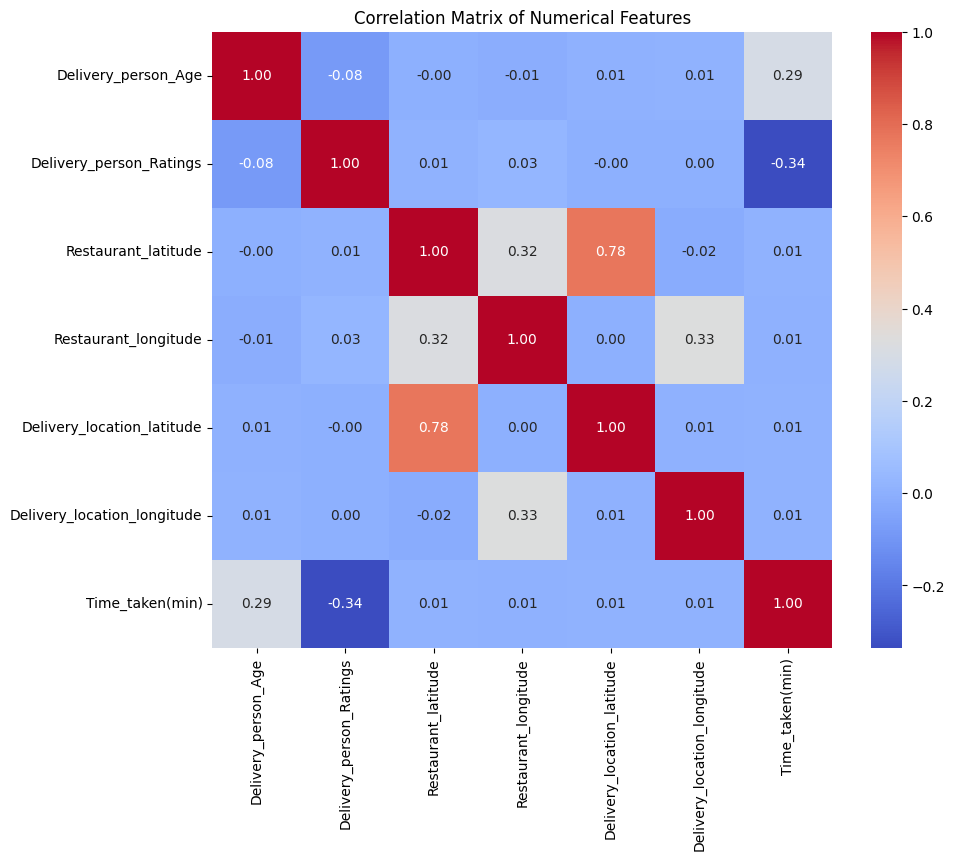

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

###  Correlation Analysis Insights

The correlation matrix reveals:
- **Time_taken(min)** shows moderate correlation with certain features
- **Age and ratings** might have some relationship
- **Location coordinates** show expected correlations

This helps us understand which features might be important for prediction.

In [ ]:
numerical=['Delivery_person_Age','Delivery_person_Ratings','Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude','Delivery_location_longitude','Time_taken(min)']

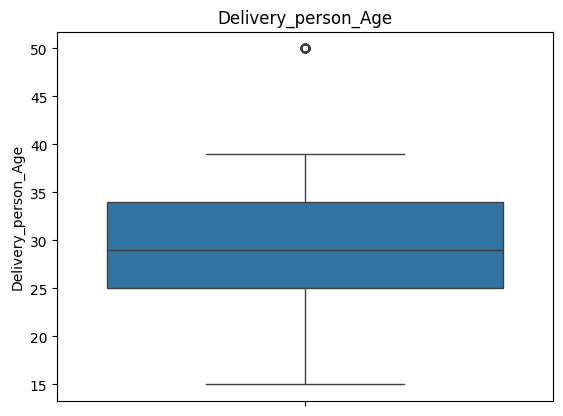

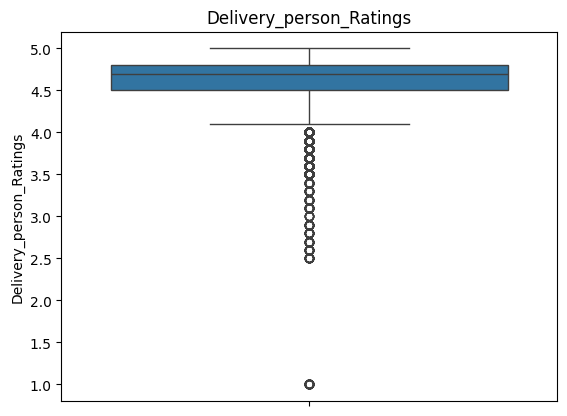

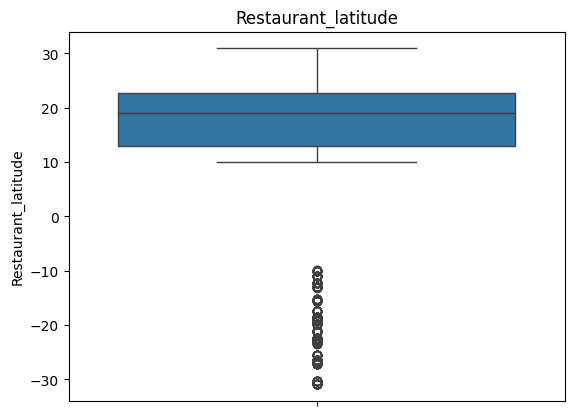

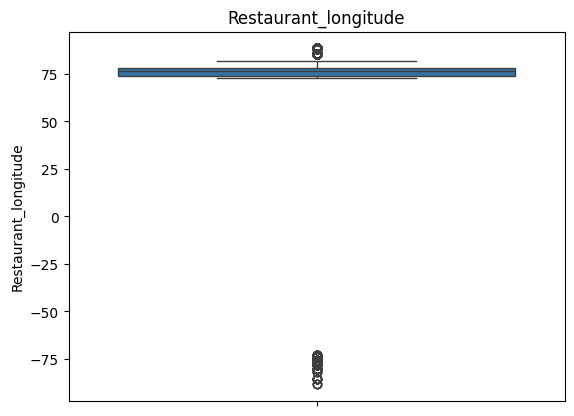

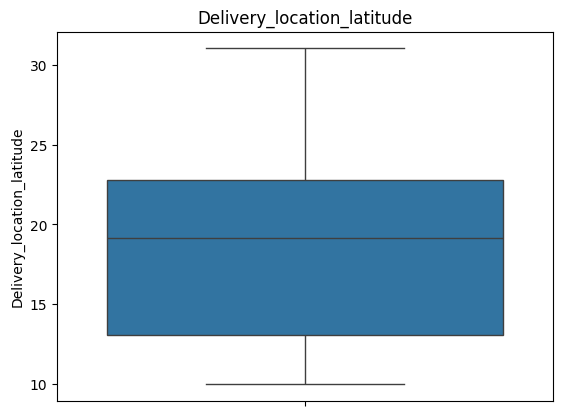

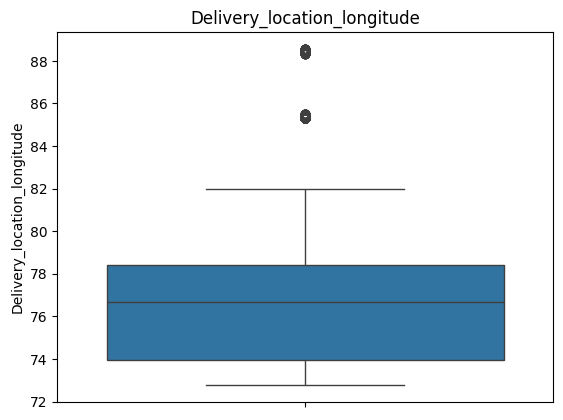

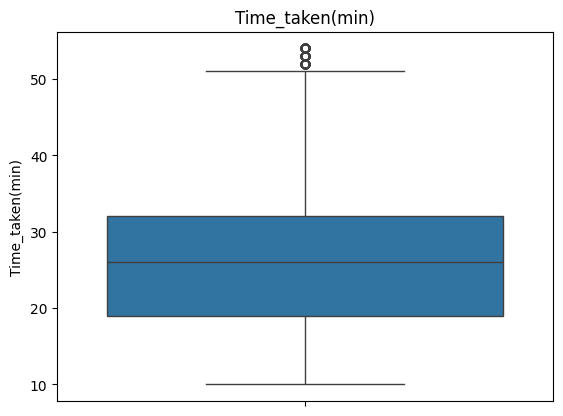

In [ ]:
# Visualize outliers
for i in numerical:
  sns.boxplot(df[i])
  plt.title(i)
  plt.show()

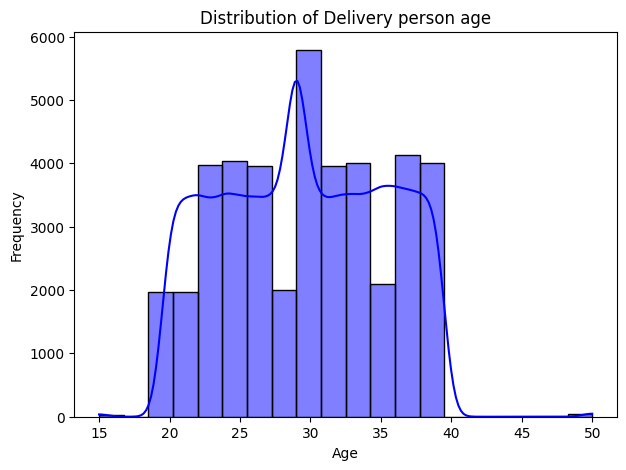

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Delivery_person_Age'],kde=True,bins=20,color='blue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person age')
plt.show()

### Delivery Person Age Distribution

The histogram shows:
- **Age range**: Mostly between 20-40 years
- **Peak distribution**: Around 25-35 years
- **Normal-like distribution**: Slightly right-skewed

This indicates a relatively young workforce, typical for delivery services.

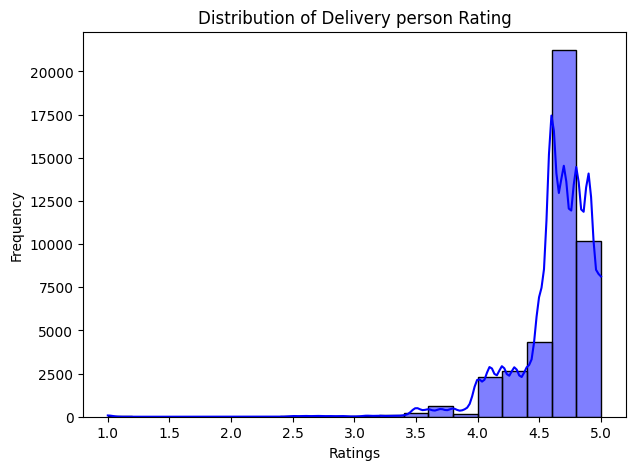

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(df['Delivery_person_Ratings'],kde=True,bins=20,color='blue')
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery person Rating')
plt.show()

### Delivery Person Ratings Distribution

Key observations:
- **Most ratings**: Between 4.5-5.0
- **High performance**: Majority of delivery persons have good ratings
- **Left-skewed distribution**: Most ratings are high

This suggests:
- Good quality service
- Possible rating inflation
- Need to consider rating as important feature

In [ ]:
print("shape of column:",df.shape)

shape of column: (41953, 11)


## STEP 3: DATA PREPROCESSING & FEATURE ENGINEERING

Now we'll create new features and prepare data for modeling:

### Why Feature Engineering?

1. **Distance Feature**: Raw coordinates aren't useful - we need actual travel distance
4. **Encoding**: Categorical variables need numerical representation
5. **Scaling**: Features should be on similar scales for many algorithms

In [ ]:
# Define Haversine Distance Function
def haversine_vectorize(lat1, lon1, lat2, lon2):

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    newlon = lon2 - lon1
    newlat = lat2 - lat1

    haver_formula = np.sin(newlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(newlon/2.0)**2

    dist = 2 * np.arcsin(np.sqrt(haver_formula ))
    km = 6367 * dist #6367 for distance in KM for miles use 3958
    return km

In [ ]:
dist_cols = ['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude','Delivery_location_longitude']

In [ ]:
df['Distance'] = df[dist_cols].apply(
    lambda x: haversine_vectorize(x[0], x[1], x[2], x[3]),
    axis=1)


/tmp/ipython-input-2342818139.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: haversine_vectorize(x[0], x[1], x[2], x[3]),


In [ ]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.023250
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.170858
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.551783
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.785510
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.206239
...,...,...,...,...,...,...,...,...,...,...,...,...
45587,1178,RANCHIRES16DEL01,35,4.2,23.371292,85.327872,23.481292,85.437872,Drinks,motorcycle,33,16.589850
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,1.488910
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,4.654271
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26,6.228480


In [ ]:
df.drop(columns=['ID','Delivery_person_ID'],axis=1,inplace=True)

In [ ]:
df

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min),Distance
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24,3.023250
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33,20.170858
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26,1.551783
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21,7.785510
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30,6.206239
...,...,...,...,...,...,...,...,...,...,...
45587,35,4.2,23.371292,85.327872,23.481292,85.437872,Drinks,motorcycle,33,16.589850
45588,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32,1.488910
45590,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16,4.654271
45591,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26,6.228480


In [ ]:
df_encoded = df.copy()


categorical_cols = ['Type_of_order', 'Type_of_vehicle']

df_encoded = pd.get_dummies(df_encoded,
                            columns=categorical_cols,
                            drop_first=True)

df_encoded.head()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min),Distance,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,Type_of_vehicle_electric_scooter,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter
0,37,4.9,22.745049,75.892471,22.765049,75.912471,24,3.023250,False,False,True,False,True,False
1,34,4.5,12.913041,77.683237,13.043041,77.813237,33,20.170858,False,False,True,False,False,True
2,23,4.4,12.914264,77.678400,12.924264,77.688400,26,1.551783,True,False,False,False,True,False
3,38,4.7,11.003669,76.976494,11.053669,77.026494,21,7.785510,False,False,False,False,True,False
4,32,4.6,12.972793,80.249982,13.012793,80.289982,30,6.206239,False,False,True,False,False,True


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41953 entries, 0 to 45592
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Delivery_person_Age                41953 non-null  int64  
 1   Delivery_person_Ratings            41953 non-null  float64
 2   Restaurant_latitude                41953 non-null  float64
 3   Restaurant_longitude               41953 non-null  float64
 4   Delivery_location_latitude         41953 non-null  float64
 5   Delivery_location_longitude        41953 non-null  float64
 6   Time_taken(min)                    41953 non-null  int64  
 7   Distance                           41953 non-null  float64
 8   Type_of_order_Drinks               41953 non-null  bool   
 9   Type_of_order_Meal                 41953 non-null  bool   
 10  Type_of_order_Snack                41953 non-null  bool   
 11  Type_of_vehicle_electric_scooter   41953 non-null  bool   


In [ ]:
std_scaler = PowerTransformer(method='yeo-johnson', standardize=True)
scaling_cols = ['Delivery_person_Age',
'Delivery_person_Ratings',
'Restaurant_latitude',
'Restaurant_longitude',
'Delivery_location_latitude',
'Delivery_location_longitude',
'Distance']
df_encoded[scaling_cols] = std_scaler.fit_transform(df_encoded[scaling_cols])

In [ ]:
X = df_encoded.drop("Time_taken(min)", axis=1)
y = df_encoded["Time_taken(min)"]

### Train-Test Split

We split data into:
- **80% Training** (28,725 samples): For model learning
- **20% Testing** (7,182 samples): For final evaluation

This split ensures:
- Enough data for training
- Unbiased evaluation on unseen data
- Representative distribution in both sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.8, random_state=123
)

In [ ]:
X_train.shape, X_test.shape

((33562, 13), (8391, 13))

## STEP 4: DEEP LEARNING MODEL BUILDING

We'll implement multiple neural network architectures to find the best performer for delivery time prediction.

---

### Why Multiple Deep Learning Architectures?

| Reason | Explanation |
|--------|-------------|
| **Different architectures** | Each captures patterns differently (dense vs sequential vs residual) |
| **No universal best** | Architecture choice depends on data structure |
| **Regularization techniques** | Dropout, BatchNorm help prevent overfitting |
| **Comparison** | Helps identify which architecture generalizes best |

---

### Models We'll Try

| Model | Type | Description |
|-------|------|-------------|
| **Simple ANN** | Feed-Forward Neural Network | Baseline deep learning model with dense layers |
| **LSTM** | Recurrent Neural Network | Long Short-Term Memory for sequence-like patterns |
| **Residual NN** | ResNet-Style Network | Skip connections to prevent vanishing gradients |

---


1. Simple ANN

In [ ]:
tf.random.set_seed(42)

model=Sequential()
model.add(Dense(256,activation='relu',input_dim=X_train.shape[1]))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(32,activation='relu'))
model.add(Dropout(0.3))
model.add(BatchNormalization())

model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse",
    metrics=['mse']
)

In [ ]:
# Convert boolean columns to int to avoid 'object' dtype issues
X_train = X_train.astype(float)
X_test = X_test.astype(float)

history = model.fit(
    np.array(X_train.values),y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 276.0142 - mse: 276.0142 - val_loss: 58.7006 - val_mse: 58.7006
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 62.2031 - mse: 62.2031 - val_loss: 56.5649 - val_mse: 56.5649
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 60.8395 - mse: 60.8395 - val_loss: 55.8350 - val_mse: 55.8350
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 60.4663 - mse: 60.4663 - val_loss: 55.5534 - val_mse: 55.5534
Epoch 5/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 59.9423 - mse: 59.9423 - val_loss: 55.8806 - val_mse: 55.8806
Epoch 6/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 59.8745 - mse: 59.8745 - val_loss: 55.2418 - val_mse: 55.2418
Epoch 7/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 59.6404 - mse: 59.6404 - val_loss: 55.0088 - val_mse: 55.0088
Epoch 8/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 59.3871 - mse: 59.3871 - val_loss: 55.3606 - val_mse: 55.3606
Epoch 9/50
420/420 ━━━

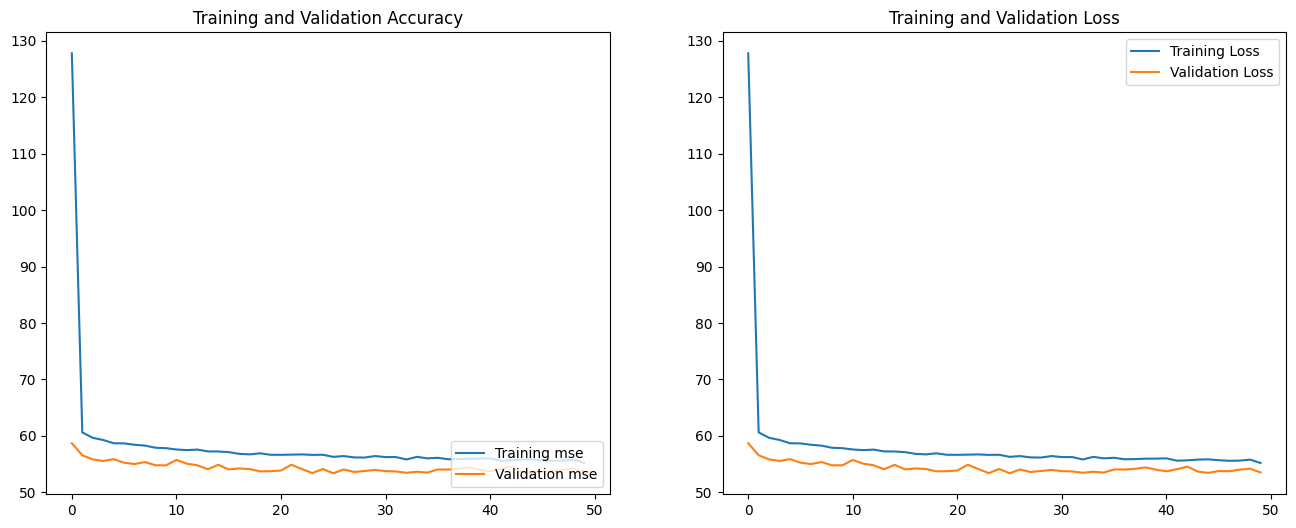

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['mse'], label='Training mse')
plt.plot(history.history['val_mse'],  label='Validation mse')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
y_pred_test = model.predict(np.array(X_test.values))
R2 = r2_score(y_test, y_pred_test)
acc=model.evaluate(np.array(X_test.values),y_test)
mse_test_lr = mean_squared_error(y_test, y_pred_test)
rmse_test_lr = mse_test_lr**0.5



print("R2 =",R2 )
print('-'*60)
print("MSE =",acc)
print("-"*60)
print("MSE for test:", mse_test_lr)
print("-"*60)
print("RMSE for test:", rmse_test_lr)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.6800 - mse: 53.6800
R2 = 0.38459497690200806
------------------------------------------------------------
MSE = [54.10242462158203, 54.10242462158203]
------------------------------------------------------------
MSE for test: 54.10243606567383
------------------------------------------------------------
RMSE for test: 7.3554358175212045


2. LSTM

In [ ]:
tf.random.set_seed(42)

# Convert to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Resahpe Because Data is not sequential
X_train_reshaped = np.reshape(X_train.values, (X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped  = np.reshape(X_test.values,  (X_test.shape[0], 1, X_test.shape[1]))

model2 = Sequential()
model2.add(LSTM(128, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model2.add(Dropout(0.3))
model2.add(BatchNormalization())
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(BatchNormalization())
model2.add(Dense(32, activation='relu'))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation='linear'))
model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history2 = model2.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=64
)

Epoch 1/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 365.0854 - mse: 365.0854 - val_loss: 77.0626 - val_mse: 77.0626
Epoch 2/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 98.5536 - mse: 98.5536 - val_loss: 60.2157 - val_mse: 60.2157
Epoch 3/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 95.5506 - mse: 95.5506 - val_loss: 59.3357 - val_mse: 59.3357
Epoch 4/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 91.4092 - mse: 91.4092 - val_loss: 60.3857 - val_mse: 60.3857
Epoch 5/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 90.0225 - mse: 90.0225 - val_loss: 58.9653 - val_mse: 58.9653
Epoch 6/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 87.2976 - mse: 87.2976 - val_loss: 58.5839 - val_mse: 58.5839
Epoch 7/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 83.4881 - mse: 83.4881 - val_loss: 58.4810 - val_mse: 58.4810
Epoch 8/50
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 82.4796 - mse: 82.4796 - val_loss: 57.5022 - val_mse: 57.5022
Epoch 9/50
420/420 ━━

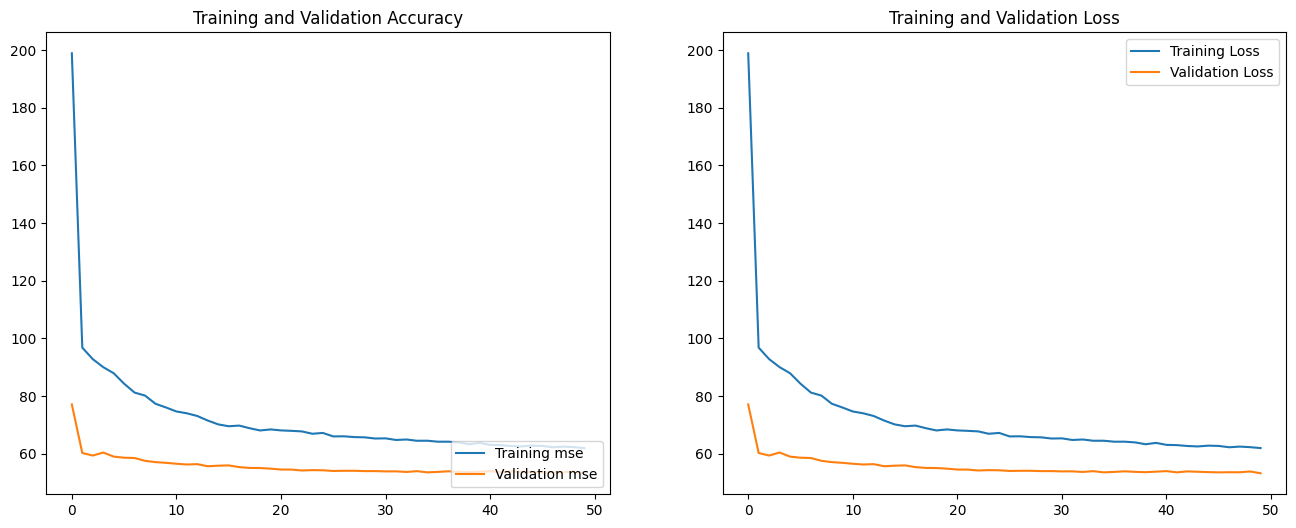

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history2.history['mse'], label='Training mse')
plt.plot(history2.history['val_mse'],  label='Validation mse')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
X_test_reshaped = np.reshape(X_test.values, (X_test.shape[0], 1, X_test.shape[1]))
y_pred_test = model2.predict(X_test_reshaped)

R2 = r2_score(y_test, y_pred_test)
loss, mse = model2.evaluate(X_test_reshaped, y_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)

print("R2 =", R2)
print('-'*60)
print("Loss =", loss)
print('-'*60)
print("MSE (from model.evaluate) =", mse)
print("-"*60)
print("MSE (manual) =", mse_test)
print("-"*60)
print("RMSE =", rmse_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 53.6627 - mse: 53.6627
R2 = 0.3864121437072754
------------------------------------------------------------
Loss = 53.942684173583984
------------------------------------------------------------
MSE (from model.evaluate) = 53.942684173583984
------------------------------------------------------------
MSE (manual) = 53.94268035888672
------------------------------------------------------------
RMSE = 7.344568085250944


3. Residual NN

In [ ]:
tf.random.set_seed(42)


input_layer = Input(shape=(X_train.shape[1],))

# First block
x = Dense(256, activation='relu')(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Residual Block 1
res = Dense(256, activation='relu')(x)
res = BatchNormalization()(res)
res = Dense(256)(res)
x = Add()([x, res])
x = tf.keras.activations.relu(x)

# Residual Block 2
res = Dense(128, activation='relu')(x)
res = BatchNormalization()(res)
res = Dense(128)(res)

# Match dimensions before addition
x = Dense(128)(x)
x = Add()([x, res])
x = tf.keras.activations.relu(x)

x = Dropout(0.3)(x)

output = Dense(1, activation='linear')(x)

model3 = Model(inputs=input_layer, outputs=output)

model3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mse']
)

In [ ]:
early_stop = EarlyStopping(patience=15, restore_best_weights=True)
history3 = model3.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 127.3420 - mse: 127.3420 - val_loss: 62.8087 - val_mse: 62.8087
Epoch 2/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 69.4661 - mse: 69.4661 - val_loss: 58.8395 - val_mse: 58.8395
Epoch 3/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 67.4162 - mse: 67.4162 - val_loss: 57.6471 - val_mse: 57.6471
Epoch 4/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 66.2198 - mse: 66.2198 - val_loss: 56.9375 - val_mse: 56.9375
Epoch 5/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 65.4143 - mse: 65.4143 - val_loss: 55.8448 - val_mse: 55.8448
Epoch 6/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 64.6592 - mse: 64.6592 - val_loss: 55.5305 - val_mse: 55.5305
Epoch 7/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 63.5174 - mse: 63.5174 - val_loss: 55.0039 - val_mse: 55.0039
Epoch 8/200
420/420 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 62.6603 - mse: 62.6603 - val_loss: 55.2329 - val_mse: 55.2329
Epoch 9/200


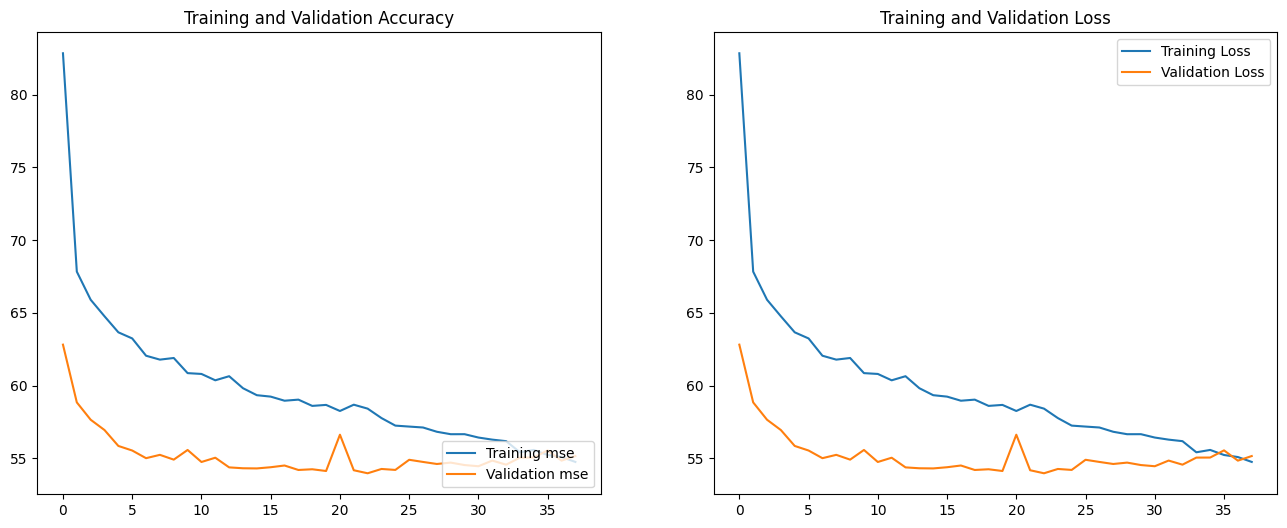

In [ ]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history3.history['mse'], label='Training mse')
plt.plot(history3.history['val_mse'],  label='Validation mse')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
y_pred_test = model.predict(X_test)
y_pred_test = y_pred_test.flatten()



R2 = r2_score(y_test, y_pred_test)
loss, mse = model.evaluate(X_test, y_test, verbose=0)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)


print("R2 =", R2)
print('-'*60)
print("Loss =", loss)
print('-'*60)
print("MSE (from model.evaluate) =", mse)
print("-"*60)
print("MSE (manual) =", mse_test)
print("-"*60)
print("RMSE =", rmse_test)

263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R2 = 0.38459497690200806
------------------------------------------------------------
Loss = 54.10242462158203
------------------------------------------------------------
MSE (from model.evaluate) = 54.10242462158203
------------------------------------------------------------
MSE (manual) = 54.10243606567383
------------------------------------------------------------
RMSE = 7.3554358175212045
